# Importing Libraries

In [1]:
# !pip install -q tensorflow-model-optimization

In [2]:
import warnings
warnings.filterwarnings('ignore')
# import tensorflow_model_optimization as tfmot

import os
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import glob
from PIL import Image
from pathlib import Path
import shutil

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB1, InceptionResNetV2, VGG16, Xception, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.regularizers import l2

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from keras import utils
from keras.models import Model
from keras.callbacks import ModelCheckpoint


2026-01-17 00:21:06.684851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768609267.160437      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768609267.302621      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768609268.451431      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768609268.451480      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768609268.451483      24 computation_placer.cc:177] computation placer alr

# Seeding

In [3]:
seed = 18114
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS']= '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
seed_everything(seed)

# Constants and configurations

In [4]:
train_folder = '/kaggle/input/driver-inattention-detection-dataset/train'
test_folder = '/kaggle/input/driver-inattention-detection-dataset/test'
valid_folder = '/kaggle/input/driver-inattention-detection-dataset/valid'

# Recommended with EfficientNetB1
IMG_SIZE = 224
TARGET_SIZE = (IMG_SIZE, IMG_SIZE)
NUM_CLASSES = 6

strategy = tf.distribute.MirroredStrategy()
BATCH_SIZE_PER_REPLICA = 64
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
WARMUP_EPOCHS = 8
EPOCHS = 30
LR = 0.001

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")

print('Devices Available: {}'.format(strategy.num_replicas_in_sync))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Devices Available: 2


I0000 00:00:1768609288.465455      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768609288.469468      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# PreProcessing Dataset

In [5]:
def read_annotations(file_path):
    annotations = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            image_name = parts[0]
            try:
                bbox = list(map(int, parts[1].split(',')))
                if len(bbox) != 5:
                    continue
                annotations.append([image_name] + bbox)
            except ValueError:
                continue
    return pd.DataFrame(annotations, columns=['image_name', 'x_min', 'y_min', 'x_max', 'y_max', 'class_id'])

def preprocess_image(image_path, target_size):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = preprocess_input(image)
    return image


def one_hot_encode_labels(labels, num_classes):
    encoder = OneHotEncoder(sparse_output=False)
    labels = np.array(labels).reshape(-1, 1)
    one_hot_labels = encoder.fit_transform(labels)
    return one_hot_labels

def preprocess_dataset(annotations, folder_path, num_classes):
    images = []
    labels = []
    for _, row in annotations.iterrows():
        image_path = os.path.join(folder_path, row['image_name'])
        image = preprocess_image(image_path, TARGET_SIZE)
        if image is None:
            continue
        images.append(image)
        labels.append(row['class_id'])
    images = np.array(images)
    one_hot_labels = one_hot_encode_labels(labels, num_classes)
    return images, one_hot_labels
    

train_annotations = read_annotations(train_folder + '/_annotations.txt')
test_annotations = read_annotations(test_folder + '/_annotations.txt')
valid_annotations = read_annotations(valid_folder + '/_annotations.txt')


train_images, train_labels = preprocess_dataset(train_annotations, train_folder, NUM_CLASSES)
test_images, test_labels = preprocess_dataset(test_annotations, test_folder, NUM_CLASSES)
valid_images, valid_labels = preprocess_dataset(valid_annotations, valid_folder, NUM_CLASSES)

## Sampling data for Quantization

In [6]:
sampled_annots = train_annotations.groupby('class_id').head(30).reset_index(drop=True)

# Get only first 6 classes
class_ids = sorted(sampled_annots['class_id'].unique())[:6]
sampled_annots = sampled_annots[sampled_annots['class_id'].isin(class_ids)]


sampled_images, sampled_labels = preprocess_dataset(
    sampled_annots,
    train_folder, 
    NUM_CLASSES
)


In [7]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)

print("Valid images shape:", valid_images.shape)
print("Valid labels shape:", valid_labels.shape)

print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

print("Test images shape:", sampled_images.shape)
print("Test labels shape:", sampled_labels.shape)

Train images shape: (11948, 224, 224, 3)
Train labels shape: (11948, 6)
Valid images shape: (1922, 224, 224, 3)
Valid labels shape: (1922, 6)
Test images shape: (985, 224, 224, 3)
Test labels shape: (985, 6)
Test images shape: (180, 224, 224, 3)
Test labels shape: (180, 6)


In [8]:
(x_train, y_train), (x_val, y_val) = (train_images, train_labels), (valid_images, valid_labels)

In [9]:
class_weights = compute_class_weight('balanced', 
                                    classes=np.unique(train_annotations['class_id']), 
                                    y=train_annotations['class_id'])
class_weight_dict = dict(enumerate(class_weights))

# Parallel Dataset creation

In [10]:
def create_datasets(x_train, y_train, x_val, y_val, batch_size):
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(len(x_train), seed=seed)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
    
    return train_dataset, val_dataset

# Building the model

In [11]:
#NOTE: we can add l1,l2 regulizers, and may start with 0.01 or similar

with strategy.scope():

    train_dataset, val_dataset = create_datasets(
        x_train, y_train, x_val, y_val, BATCH_SIZE
    )

    #Optimizer definition
    optimizer = optimizer=Adam(learning_rate=LR)
    
    #Callbacks definition
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(filepath=checkpoint_prefix,
                                save_best_only=True,
                                save_weights_only=True)
    tensorboard = TensorBoard(log_dir='./logs')
    
    CALL_BACKS = [reduce_lr, early_stopping, checkpoint, tensorboard]
    
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))


    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.2)(x)
    x = tf.keras.layers.RandomZoom(0.2)(x)
    x = tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
    x = tf.keras.layers.RandomBrightness(0.3)(x) 
    x = tf.keras.layers.RandomHue(factor=0.5)(x)
    x = tf.keras.layers.RandomContrast(0.4)(x) 
    x = tf.keras.layers.RandomSaturation(factor=0.2)(x)
    
    base_model = VGG16(weights='imagenet',
                                include_top=False,
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model(x)
    x = GlobalAveragePooling2D()(x)

    
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.005))(x)  # Increased
    x = BatchNormalization()(x)  # Add BN for stability
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.005))(x)  # Extra layer
    x = Dropout(0.3)(x)  # Lower dropout in second layer

    
    output = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=output)

    model.compile(optimizer = optimizer,loss='categorical_crossentropy',
                  metrics=  ['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_hue (RandomHue)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_saturation               │ (None, 224, 224, 3)    │             0 │
│ (RandomSaturation)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,771,974 (60.17 MB)

 Trainable params: 1,055,238 (4.03 MB)

 Non-trainable params: 14,716,736 (56.14 MB)

# Warmingup the model

In [13]:
warmup_history = model.fit(train_dataset, 
                    epochs=WARMUP_EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1768609493.213582      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768609494.224260      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3581 - loss: 8.0848INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 396ms/step - accuracy: 0.3588 - loss: 8.0763 - val_accuracy: 0.5109 - val_loss: 6.7420 - learning_rate: 0.0010
Epoch 2/8
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 432ms/step - accuracy: 0.5017 - loss: 5.6158 - val_accuracy: 0.7118 - val_loss: 4.4157 - learning_rate: 0.0010
Epoch 3/8
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 458ms/step - accuracy: 0.5439 - loss: 4.3961 - val_accuracy: 0.7784 - val_loss: 3.3262 - learning_rate: 0.0010
Epoch 4/8
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 450ms/step - accuracy: 0.5771 - loss: 3.4773 - val_accuracy: 0.7367 - val_loss: 2.8142 - learning_rate: 0.0010
Epoch 5/8
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 461ms/step - accuracy: 0.5871 - loss: 2.8580 - val_accuracy: 0.6103 - val_loss: 2.7352 - learning_rate: 0.0010
Epoch 6/8
94/94 ━━━━━━━━━━━━━━━━━━━━

# Model evaluation

In [14]:
def evaluate_histories(history1, history2):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'] + history2.history['accuracy'])
    plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'] + history2.history['loss'])
    plt.plot(history1.history['val_loss'] + history2.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")


def evaluate_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

# Warmup results

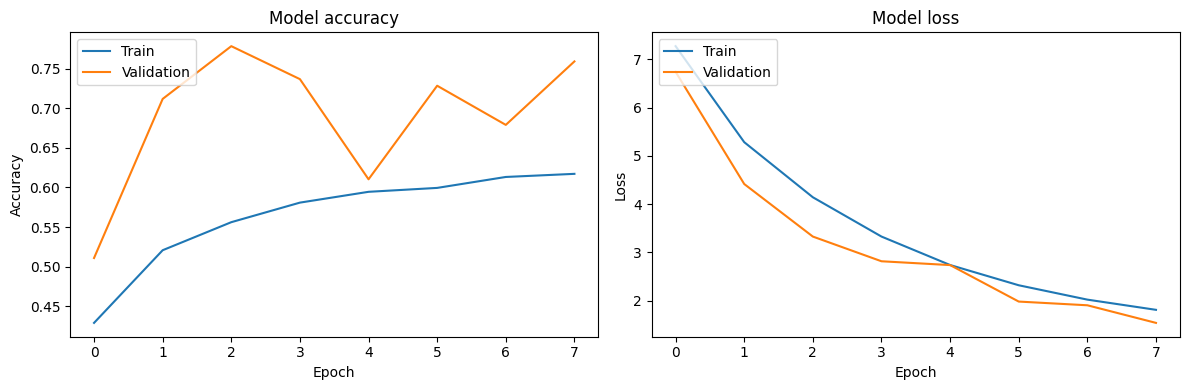

2026-01-17 00:30:39.160147: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7254 - loss: 1.5935
Test accuracy: 0.7381, Test loss: 1.5635


In [15]:
evaluate_history(warmup_history)

In [16]:
print(len(base_model.layers))

19


# Fine Tuning

In [17]:
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    model.compile(optimizer=Adam(learning_rate= LR * 0.1),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


tuned_history = model.fit(train_dataset, 
                    epochs=EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict)

Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 34 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
94/94 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5031 - loss: 2.0650 - val_accuracy: 0.7237 - val_loss: 1.7608 - learning_rate: 1.0000e-04
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7540 - loss: 1.2121 - val_accuracy: 0.9188 - val_loss: 0.8938 - learning_rate: 1.0000e-04
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8183 - loss: 1.0294 - val_accuracy: 0.5271 - val_loss: 1.8035 - learning_rate: 1.0000e-04
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8432 - loss: 0.9265 - val_accuracy: 0.9069 - val_loss: 0.8361 - learning_rate: 1.0000e-04
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8677 - loss: 0.8239 - val_accuracy: 0.9037 - val_loss: 0.7830 - learning_rate: 1.0000e-04
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.

# Final results

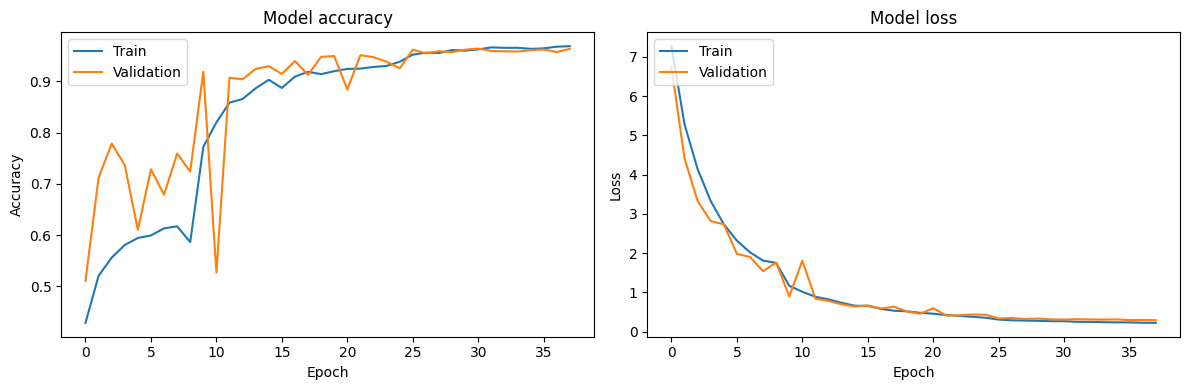

2026-01-17 01:20:40.194816: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.9707 - loss: 0.2545
Test accuracy: 0.9695, Test loss: 0.2566


In [18]:
evaluate_histories(warmup_history, tuned_history)

# Downloading the final model

In [19]:
model.save('model.keras')
print("✓ Model saved as model.keras")

model_info = {
    'img_size': 224,
    'num_classes': 6,
    'class_names': ['safe_driving', 'texting_right', 'talking_right', 
                    'texting_left', 'talking_left', 'drinking'],
    'architecture': 'EfficientNetB1',
    'input_shape': [224, 224, 3],
    'preprocessing': 'efficientnet_preprocess_input'
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("✓ Model info saved")

from IPython.display import FileLink
FileLink('model.keras')
FileLink('model_info.json')

✓ Model saved as model.keras
✓ Model info saved


/kaggle/working/model_info.json

## Quantization and Prunning

In [20]:
DATA_PATH = "/kaggle/input/driver-inattention-detection-dataset/train"           
METADATA_PATH = r"archive\metadata"    
SMAPLED_DATA_PATH = "/kaggle/working/sampled_dataset"    
COMPRESSED_MODEL_PATH = "/kaggle/working/compressed_models"
CLASSES_FILE_PATH = "/kaggle/input/driver-inattention-detection-dataset/train/_classes.txt"                     
ANNOTATIONS_FILE_PATH = "/kaggle/input/driver-inattention-detection-dataset/train/_annotations.txt"            
SAMPLE_SIZE = 30   

os.makedirs(COMPRESSED_MODEL_PATH, exist_ok=True)




In [21]:
def prepare_quantization_dataset():
    """Prepare dataset for quantization that matches training exactly"""
    
    # 1. Load and sample annotations
    annotations = read_annotations(ANNOTATIONS_FILE_PATH)
    
    # Simple sampling: 30 samples from first 6 classes
    sampled_annots = annotations.groupby('class_id').head(30)
    first_6_classes = sorted(sampled_annots['class_id'].unique())[:6]
    sampled_annots = sampled_annots[sampled_annots['class_id'].isin(first_6_classes)]
    
    # 2. Preprocess using your EXACT training function
    quantization_images, _ = preprocess_dataset(sampled_annots, train_folder, NUM_CLASSES)
    
    return quantization_images

def representative_dataset():
    """Clean representative dataset using same preprocessing as training"""
    print(f"🔍 Preparing quantization dataset...")
    
    quantization_images = prepare_quantization_dataset()
    print(f"   Using {len(quantization_images)} preprocessed images")
    
    for i in range(len(quantization_images)):
        img = np.expand_dims(quantization_images[i], axis=0).astype(np.float32)
        yield [img]

In [22]:
def quantize_dynamic():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset 

    ## Latest additions
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,  # Enable TFLite ops
        tf.lite.OpsSet.SELECT_TF_OPS,    # Enable TF ops if needed
    ]
    
    # These flags enable XNNPACK
    converter.experimental_new_converter = True
    converter.experimental_new_quantizer = True

    ##

    
    tflite_model = converter.convert()
    
    
    with open(COMPRESSED_MODEL_PATH + "/vgg16_dynamic.tflite", 'wb') as f:
            f.write(tflite_model)

In [23]:
def quantize_float16():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    converter.representative_dataset = representative_dataset 

    ## Latest additions
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,  # Enable TFLite ops
        tf.lite.OpsSet.SELECT_TF_OPS,    # Enable TF ops if needed
    ]
    
    # These flags enable XNNPACK
    converter.experimental_new_converter = True
    converter.experimental_new_quantizer = True

    ##
    
    tflite_model = converter.convert()

    with open(COMPRESSED_MODEL_PATH + "/vgg16_float16.tflite", 'wb') as f:
        f.write(tflite_model)

In [24]:
def quantize_int8(images_folder=SMAPLED_DATA_PATH, num_samples=100, image_size=(IMG_SIZE,IMG_SIZE)):
    
    def representative_dataset_gen():
        image_paths = _collect_diverse_images(images_folder, num_samples)
        print(f"Using {len(image_paths)} diverse images for calibration...")
        
        for i, img_path in enumerate(image_paths):
            if i % 20 == 0:
                print(f"  Processing image {i+1}/{len(image_paths)}...")
            
            img = Image.open(img_path).convert('RGB')
            img = img.resize(image_size)
            img = np.array(img).astype(np.float32) / 255.0
            img = np.expand_dims(img, axis=0)
            yield [img]
    
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.uint8
    converter.representative_dataset = representative_dataset 
    
    tflite_model = converter.convert()
    
    with open(COMPRESSED_MODEL_PATH + "/vgg16_int8.tflite", 'wb') as f:
        f.write(tflite_model)

In [25]:
quantize_dynamic()

INFO:tensorflow:Assets written to: /tmp/tmpsjjbnyh6/assets


INFO:tensorflow:Assets written to: /tmp/tmpsjjbnyh6/assets


Saved artifact at '/tmp/tmpsjjbnyh6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132772406845584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406849040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406850768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13277240685268

W0000 00:00:1768612850.278871      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768612850.278918      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1768612850.304526      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


🔍 Preparing quantization dataset...
   Using 180 preprocessed images


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


In [26]:
quantize_float16()

INFO:tensorflow:Assets written to: /tmp/tmple4maabb/assets


INFO:tensorflow:Assets written to: /tmp/tmple4maabb/assets


Saved artifact at '/tmp/tmple4maabb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132772406845584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406849040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406850768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13277240685268

W0000 00:00:1768612952.520915      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768612952.520941      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [27]:
quantize_int8("/kaggle/working/sampled_dataset")

INFO:tensorflow:Assets written to: /tmp/tmpocgy84uv/assets


INFO:tensorflow:Assets written to: /tmp/tmpocgy84uv/assets


Saved artifact at '/tmp/tmpocgy84uv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132772406845584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406846736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406849040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406850768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406851536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132772406852880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13277240685268

W0000 00:00:1768612956.316260      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768612956.316286      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


🔍 Preparing quantization dataset...
   Using 180 preprocessed images


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [28]:
models_to_test = [
    "/kaggle/working/compressed_models/vgg16_dynamic.tflite",
    "/kaggle/working/compressed_models/vgg16_float16.tflite",
    "/kaggle/working/compressed_models/vgg16_int8.tflite"
]

import time

for model_path in models_to_test:
    if not os.path.exists(model_path):
        continue
    
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    
    correct = 0
    total_time = 0
    samples = 50  # Test fewer for speed measurement
    
    for i in range(samples):
        # Prepare input
        img = test_images[i:i+1]
        if input_details['dtype'] == np.uint8:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.float32)
        
        # Time inference
        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])
        end = time.perf_counter()
        
        total_time += (end - start)
        
        # Check accuracy
        pred = np.argmax(output[0])
        true = np.argmax(test_labels[i])
        if pred == true:
            correct += 1
    
    # Results
    acc = correct / samples
    avg_time_ms = (total_time / samples) * 1000
    print(f"{os.path.basename(model_path):25} → Acc: {acc:.3f} | Speed: {avg_time_ms:.1f}ms/img")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


vgg16_dynamic.tflite      → Acc: 0.980 | Speed: 398.2ms/img
vgg16_float16.tflite      → Acc: 0.960 | Speed: 403.3ms/img
vgg16_int8.tflite         → Acc: 0.560 | Speed: 405.8ms/img


In [29]:
import numpy as np
import tensorflow as tf

def debug_tflite_model(model_path, test_images, test_labels, num_samples=5):
    """
    Comprehensive debug for low accuracy TFLite models.
    """
    print(f"\n{'='*60}")
    print(f"🔧 DEBUGGING: {os.path.basename(model_path)}")
    print(f"{'='*60}")
    
    # 1. Load and inspect model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    print(f"📋 Model Info:")
    print(f"   Input dtype: {input_details['dtype']}")
    print(f"   Input shape: {input_details['shape']}")
    print(f"   Output dtype: {output_details['dtype']}")
    
    if 'quantization' in input_details:
        scale, zero_point = input_details['quantization']
        print(f"   Input quant: scale={scale}, zero_point={zero_point}")
    
    # 2. Test original Keras model (if available)
    keras_model_path = "/kaggle/working/EfficientNetB1_backbone/model.keras"
    if os.path.exists(keras_model_path):
        print(f"\n🔍 Comparing with original Keras model...")
        original_model = tf.keras.models.load_model(keras_model_path)
        
        # Test same images
        for i in range(min(3, num_samples)):
            img = test_images[i:i+1].astype(np.float32)
            
            # Keras prediction
            keras_pred = original_model.predict(img, verbose=0)
            keras_class = np.argmax(keras_pred[0])
            
            # TFLite prediction
            if input_details['dtype'] == np.uint8:
                tflite_img = (img * 255).astype(np.uint8)
            else:
                tflite_img = img.astype(np.float32)
            
            interpreter.set_tensor(input_details['index'], tflite_img)
            interpreter.invoke()
            tflite_output = interpreter.get_tensor(output_details['index'])
            
            if output_details['dtype'] == np.uint8:
                out_scale, out_zero = output_details['quantization']
                tflite_output = (tflite_output.astype(np.float32) - out_zero) * out_scale
            
            tflite_class = np.argmax(tflite_output[0])
            true_class = np.argmax(test_labels[i])
            
            print(f"\n   Sample {i}:")
            print(f"   True class: {true_class}")
            print(f"   Keras pred: {keras_class} (prob: {np.max(keras_pred):.3f})")
            print(f"   TFLite pred: {tflite_class} (prob: {np.max(tflite_output):.3f})")
            print(f"   Keras probs: {[f'{p:.3f}' for p in keras_pred[0]]}")
            print(f"   TFLite probs: {[f'{p:.3f}' for p in tflite_output[0]]}")
    
    # 3. Check if outputs are reasonable
    print(f"\n📊 Output distribution check:")
    all_outputs = []
    for i in range(min(10, len(test_images))):
        img = test_images[i:i+1]
        if input_details['dtype'] == np.uint8:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.float32)
        
        interpreter.set_tensor(input_details['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])
        
        if output_details['dtype'] == np.uint8:
            out_scale, out_zero = output_details['quantization']
            output = (output.astype(np.float32) - out_zero) * out_scale
        
        all_outputs.append(output[0])
    
    avg_probs = np.mean(all_outputs, axis=0)
    print(f"   Average probabilities: {[f'{p:.3f}' for p in avg_probs]}")
    
    # If all probabilities are similar (~0.1667 for 6 classes), model is random
    if np.allclose(avg_probs, [1/6]*6, atol=0.05):
        print(f"   ⚠️  WARNING: Model outputs are nearly uniform - it's predicting randomly!")
    
    return interpreter

# Run debug
debug_interpreter = debug_tflite_model(
    "/kaggle/working/compressed_models/vgg16_dynamic.tflite",
    test_images, 
    test_labels
)


🔧 DEBUGGING: vgg16_dynamic.tflite
📋 Model Info:
   Input dtype: <class 'numpy.float32'>
   Input shape: [  1 224 224   3]
   Output dtype: <class 'numpy.float32'>
   Input quant: scale=0.0, zero_point=0

📊 Output distribution check:
   Average probabilities: ['0.399', '0.084', '0.000', '0.398', '0.015', '0.100']


In [30]:
# def prune_model(output_path=COMPRESSED_MODEL_PATH , sparsity=0.5):
    
#     pruning_params = {
#         'pruning_schedule': tfmot.sparsity.keras.ConstantSparsity(
#             target_sparsity=sparsity,
#             begin_step=0,
#             end_step=100,
#             frequency=100
#         ),
#         'block_size': (1, 1),
#         'block_pooling_type': 'AVG',
#     }
    
#     model_for_pruning = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)
    
#     pruned_model.set_weights(model.get_weights())
    
#     pruned_model.compile(
#         optimizer='adam',
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )
    
#     final_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
#     final_model.save(output_path)